# CMS Hospital Ratings vs Patient Outcomes
**Research Question:** Is there a correlation between Center for Medicare & Medicaid Services (CMS) hospital overall ratings and patient outcomes, specifically 30-day mortality rates, across the U.S. hospitals?

**Source(s):** 
 - https://data.cms.gov/provider-data/dataset/xubh-q36u
 - https://data.cms.gov/provider-data/dataset/ynj2-r877

---

## Step 1: Setup & Pre-processing 

In [37]:
import pandas as pd 
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


---

## Step 2: Data Retrieval

In [38]:
def fetch_data(dataset_id):
    # Fetches dataset directly from CMS using the official CSV download endpoint
    url = f"https://data.cms.gov/provider-data/api/1/datastore/query/{dataset_id}/0/download?format=csv"
    
    print(f"Fetching dataset: {dataset_id} ...")
    df = pd.read_csv(url, dtype=str)
    print(f"  Extraction complete! Total rows: {len(df):,}, Columns: {len(df.columns)}\n")
    return df

HOSPITAL_ID      = "xubh-q36u"
COMPLICATIONS_ID = "ynj2-r877"

print("Retrieving data from CMS...\n")
hospital_info = fetch_data(HOSPITAL_ID)
print("Hospital Information Gathered Successfully!")

complications = fetch_data(COMPLICATIONS_ID)
print("Complications and Death Data Gathered Successfully!")

Retrieving data from CMS...

Fetching dataset: xubh-q36u ...
  Extraction complete! Total rows: 5,426, Columns: 38

Hospital Information Gathered Successfully!
Fetching dataset: ynj2-r877 ...
  Extraction complete! Total rows: 95,780, Columns: 18

Complications and Death Data Gathered Successfully!


---
## Step 3: Explore the Data

Take a look at the current structure of the data to understand the available information.

In [39]:
print("Hospital Information: First 3 Rows:")
display(hospital_info.head(3))

print("\n Hospital Information: Columnns")
print(list(hospital_info.columns))

Hospital Information: First 3 Rows:


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,NaN,8,8,NaN,12,11,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,NaN,8,8,NaN,12,12,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,NaN,8,8,NaN,12,10,NaN



 Hospital Information: Columnns
['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type', 'Hospital Ownership', 'Emergency Services', 'Meets criteria for birthing friendly designation', 'Hospital overall rating', 'Hospital overall rating footnote', 'MORT Group Measure Count', 'Count of Facility MORT Measures', 'Count of MORT Measures Better', 'Count of MORT Measures No Different', 'Count of MORT Measures Worse', 'MORT Group Footnote', 'Safety Group Measure Count', 'Count of Facility Safety Measures', 'Count of Safety Measures Better', 'Count of Safety Measures No Different', 'Count of Safety Measures Worse', 'Safety Group Footnote', 'READM Group Measure Count', 'Count of Facility READM Measures', 'Count of READM Measures Better', 'Count of READM Measures No Different', 'Count of READM Measures Worse', 'READM Group Footnote', 'Pt Exp Group Measure Count', 'Count of Facility Pt Exp Measures', 'Pt Exp Group Footnot

In [40]:
print("Complications & Deaths: First 3 Rows:")
display(hospital_info.head(3))

print("\n Unique Measures ID in Dataset")
print(sorted(complications['Measure ID'].unique()))

Complications & Deaths: First 3 Rows:


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,NaN,8,8,NaN,12,11,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,NaN,8,8,NaN,12,12,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,NaN,8,8,NaN,12,10,NaN



 Unique Measures ID in Dataset
['COMP_HIP_KNEE', 'Hybrid_HWM', 'MORT_30_AMI', 'MORT_30_CABG', 'MORT_30_COPD', 'MORT_30_HF', 'MORT_30_PN', 'MORT_30_STK', 'PSI_03', 'PSI_04', 'PSI_06', 'PSI_08', 'PSI_09', 'PSI_10', 'PSI_11', 'PSI_12', 'PSI_13', 'PSI_14', 'PSI_15', 'PSI_90']


## Step 4: Clean and Fliter Data

We will conduct the following to the current dataset:
- Only keep the relevant columns for each dataset
- Filter the deaths and Complicationd data to six 30-day mortality measures
- Remove hospitals with missing or non-numerical scores
- Convert fields to appropraite data types

In [41]:
# Clean Hospital Information
clean_data = hospital_info[[
    'Facility ID', 'Facility Name', 'City/Town', 'State', 'Hospital Type', 'Hospital overall rating'
]].copy()

clean_data.columns = ['facility_id', 'facility_name', 'city', 'state', 'hospital_type', 'star_rating']

# Remove rows without star rating
# non numerical
clean_data = clean_data[pd.to_numeric(clean_data['star_rating'], errors='coerce').notna()]
clean_data['star_rating'] = clean_data['star_rating'].astype(int)

print(f"Hospitals with valid star rating: {len(clean_data):,}")

Hospitals with valid star rating: 2,866


In [42]:
# Filter Complications Data to 30-Day Mortality
mortality = [
    'MORT_30_AMI',   #Heart Attack
    'MORT_30_HF',    #Heart Failure
    'MORT_30_PN',    #Pneumonia
    'MORT_30_COPD',  #COPD
    'MORT_30_STK',   #Stroke
    'MORT_30_CABG',  #CABG Surgery
]
filtered_comp = complications[
    complications['Measure ID'].isin(mortality)
    ][['Facility ID', 'Measure ID', 'Measure Name', 'Score']].copy()

filtered_comp.columns = ['facility_id', 'measure_id', 'measure_name', 'score']

# Remove rows without mortality
# non numerical
filtered_comp = filtered_comp[pd.to_numeric(filtered_comp['score'], errors='coerce').notna()]
filtered_comp['score'] = filtered_comp['score'].astype(float)

print(f"Total valid mortality records for 30-days: {len(filtered_comp):,}")

Total valid mortality records for 30-days: 14,474


## Step 5: Calculate Average Mortality Score for Each Hospital

In [43]:
average_mort = filtered_comp.groupby('facility_id')['score'].mean().reset_index()
average_mort.columns = ['facility_id','avg_mortality_rate']

print(f"Hospitals with averaged mortalitity scores: {len(average_mort):,}")
display(average_mort.head())

Hospitals with averaged mortalitity scores: 3,684


,facility_id,avg_mortality_rate
0,010001,10.983333
1,010005,14.275000
2,010006,12.183333
3,010007,16.666667
4,010008,15.000000


## Step 6: Merge Datasets

Merge hospital rating with average mortality scores using Facility ID to create a single DataFrame.

In [44]:
df = pd.merge(clean_data, average_mort, on='facility_id', how='inner')
df = df.dropna(subset=['star_rating', 'avg_mortality_rate'])

print(f"Final merged dataset includes {len(df):,} hospitals")

Final merged dataset includes 2,812 hospitals


## Step 7: Descriptive Statistics per Rating

Identify if any correlation or pattern emergies from avergae mortality rating and CMS rating

In [45]:
summary = df.groupby('star_rating')['avg_mortality_rate'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
).round(2)

print("Summary Statistics: 30-Day Mortality Rate based on Star Rating")
display(summary)

Summary Statistics: 30-Day Mortality Rate based on Star Rating


,Count,Mean,Median,Std,Min,Max
star_rating,,,,,,
1,227,12.98,13.05,1.70,8.80,19.06
2,640,12.51,12.40,1.63,7.53,20.20
3,921,12.08,12.02,1.68,7.78,19.55
4,744,11.55,11.45,1.64,7.72,17.00
5,280,10.72,10.68,1.76,6.00,16.70


## Step 8: Visualizations

### 1) Average 30-Day Mortality by CMS Star Rating

Text(0, 0.5, 'Average 30-Day Mortality Rate (%)')

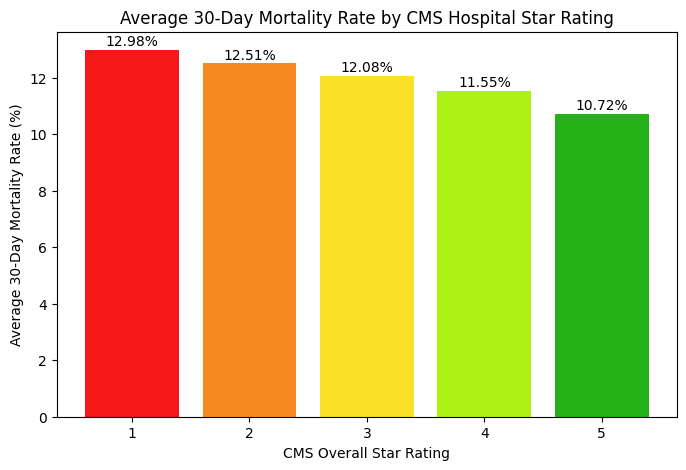

In [46]:
mort_v_rating = df.groupby('star_rating')['avg_mortality_rate'].mean().reset_index()
colors = ["#f41818", "#f88820", "#fae128", "#acf215", "#22b218"]

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    mort_v_rating['star_rating'].astype(str),
    mort_v_rating['avg_mortality_rate'],
    color=colors
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{bar.get_height():,.2f}%',
        ha='center',va='bottom'
    )

ax.set_title('Average 30-Day Mortality Rate by CMS Hospital Star Rating')
ax.set_xlabel('CMS Overall Star Rating')
ax.set_ylabel('Average 30-Day Mortality Rate (%)')

### 2) Mortality Rate by Condition and CMS Star Rating

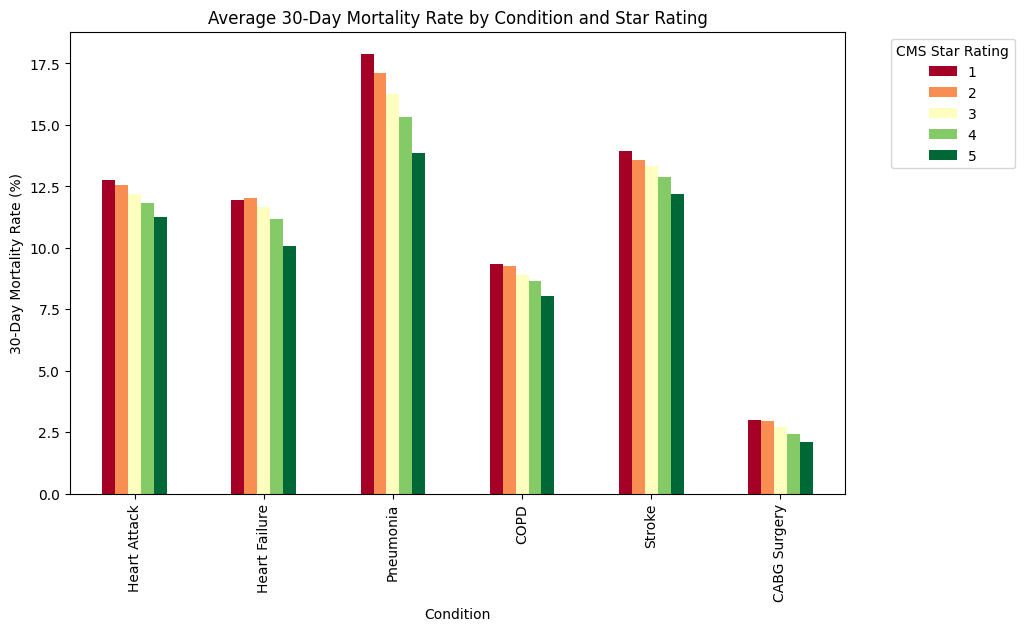

In [ ]:
cond_v_rating = pd.merge(
    filtered_comp,
    clean_data[['facility_id', 'star_rating']],
    on='facility_id',
    how='inner'
    )

star_avg = cond_v_rating.groupby(['measure_id', 'star_rating'])['score'].mean().reset_index()

map_labels = {
    'MORT_30_AMI':  'Heart Attack',
    'MORT_30_HF':   'Heart Failure',
    'MORT_30_PN':   'Pneumonia',
    'MORT_30_COPD': 'COPD',
    'MORT_30_STK':  'Stroke',
    'MORT_30_CABG': 'CABG Surgery'
}
star_avg['measure_label'] = star_avg['measure_id'].map(map_labels)

pivot_table = star_avg.pivot(index='measure_label', columns='star_rating', values='score')

# Reindex to match the order
pivot_table = pivot_table.reindex(list(map_labels.values()))

fig, ax = plt.subplots(figsize=(10,6))
pivot_table.plot(kind='bar', ax=ax, colormap='RdYlGn')

ax.set_title('Average 30-Day Mortality Rate by Condition and Star Rating')
ax.set_xlabel('Condition')
ax.set_ylabel('30-Day Mortality Rate (%)')

ax.legend(title='CMS Star Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

## Step 9: Conclusion and Summary

This sectionc presents findings and analysis conclusion

In [36]:
rating_summary = df.groupby('star_rating')['avg_mortality_rate'].mean().round(2)

star_1 = rating_summary.loc[1]
star_5 = rating_summary.loc[5]
diff = round(star_1 - star_5, 2)
correlation = df['star_rating'].corr(df['avg_mortality_rate']).round(3)

print(f"""
    CMS HOSPITALSTAR RATING VS PATIENT OUTCOMES SUMMARY
      
    This analysis investigated whether there is a relationship between CMS 
    hospital star ratings and 30-day mortality rates for six of the most 
    common fatal conditions: heart attack, heart failure, pneumonia, COPD, 
    stroke, and CABG surgery.

    MORTALITY RATES BY STAR RATING:
        - Hospitals with a 1-star rating had the highest average 30-day mortality rate at {star_1:.2f}%
        - Hospitals with a 5-star rating had the lowest average 30-day mortality rate at {star_5:.2f}%
        - The difference in mortality rates between 1-star and 5-star hospitals is {diff:.2f}
        - The correlation between star ratings and mortality rates is {correlation}

    CONCLUSION:
        The data reveal a clear inverse relationship between CMS hospital star ratings and 30-day 
        mortality rates across all six conditions analyzed. The negative correltation of {correlation} 
        indicates that hospitals rating 4 or 5 stars consistently consistently outperform those with 
        1 or 2 stars, supporting the notion that higher star ratings correspond to better patient 
        outcomes. This pattern aligns with the overall intended purpose of the CMS star rating system, 
        to summarize hospital performance directly from EHR data in a way that is meaningful and predictive.
    """)


    CMS HOSPITALSTAR RATING VS PATIENT OUTCOMES SUMMARY

    This analysis investigated whether there is a relationship between CMS 
    hospital star ratings and 30-day mortality rates for six of the most 
    common fatal conditions: heart attack, heart failure, pneumonia, COPD, 
    stroke, and CABG surgery.

    MORTALITY RATES BY STAR RATING:
        - Hospitals with a 1-star rating had the highest average 30-day mortality rate at 12.98%
        - Hospitals with a 5-star rating had the lowest average 30-day mortality rate at 10.72%
        - The difference in mortality rates between 1-star and 5-star hospitals is 2.26
        - The correlation between star ratings and mortality rates is -0.334

    CONCLUSION:
        The data reveal a clear inverse relationship between CMS hospital star ratings and 30-day 
        mortality rates across all six conditions analyzed. The negative correltation of -0.334 
        indicates that hospitals rating 4 or 5 stars consistently consistently